# 06 - Feature Selection and PCA (PuneBite Analyzer)

**Objective:** find out which of our many input features actually matter, remove the redundant ones, and test whether PCA can compress them.
**Input:** `data/processed/restaurants_clean.csv`
**Output:** a ranked and consensus feature list (`ml/models/selected_features.json`) and a PCA summary
**Syllabus link:** Unit IV (dimensionality reduction: feature selection, PCA; overfitting/underfitting; K-Fold validation). This is our version of the syllabus case study "Feature selection in healthcare dataset": same techniques, applied to restaurants.

We work with the **no-votes feature set** (Scenario B from notebooks 04 and 05), but with **all 86 amenity columns** instead of the 30 common ones, so selection has something to choose from.

> **Important rule:** ranking features with the labels is fine for exploring, but any score we *report* must do the selection **inside** cross-validation. Otherwise the labels leak into the evaluation (we demonstrate this in section 6).

In [1]:
import os, sys, json, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from ml import features as feat

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/processed/restaurants_clean.csv")
cols = list(df.columns)
amenity_cols = cols[cols.index("star1_pct") + 1 : cols.index("spam_review_count")]
rated = df[df["has_rating"]].copy().reset_index(drop=True)
y = (rated["rating"] >= 4.0).astype(int)
print("Rated restaurants:", len(rated), "| highly rated share:", round(y.mean(), 3))

Rated restaurants: 7669 | highly rated share: 0.112


## 1. Build the full feature matrix
`min_amenity_share=0` keeps **all** amenities. Numbers are scaled and categories one-hot encoded, giving one numeric column per feature.

In [2]:
spec_full = feat.fit_feature_spec(df, amenity_cols, min_amenity_share=0.0)
X_raw, info = feat.make_features(rated, spec_full, with_votes=False)

pre = ColumnTransformer([
    ("num", StandardScaler(), info["numeric"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), info["categorical"]),
    ("bin", "passthrough", info["binary"]),
], sparse_threshold=0)
X_mat = pre.fit_transform(X_raw)
names = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]
X = pd.DataFrame(X_mat, columns=names)

def group_of(n):
    if n in info["numeric"]: return "numeric"
    if n.startswith("type_grp_"): return "restaurant type"
    if n.startswith("locality_grp_"): return "locality"
    if n.startswith("cuis_"): return "cuisine"
    return "amenity"

# Zero-variance columns (amenities that never occur among rated restaurants) carry no information: drop them first
const_cols = [n for n in names if X[n].std() == 0]
X = X.drop(columns=const_cols)
names = list(X.columns)
print(f"Dropped {len(const_cols)} constant columns: {const_cols}")

groups = pd.Series({n: group_of(n) for n in names})
print("Total features:", X.shape[1])
groups.value_counts()

Dropped 1 constant columns: ['egg_preparations']
Total features: 150


amenity            85
locality           31
cuisine            15
restaurant type    14
numeric             5
Name: count, dtype: int64

## 2. Step 1: drop near-constant features (variance filter)
A yes/no feature that is almost always 0 carries almost no information and can only add noise.

Amenity columns: 85
  prevalence below 0.5%: 40 columns
  prevalence below 1.0%: 55 columns
  prevalence below 2.0%: 62 columns
  prevalence below 5.0%: 72 columns


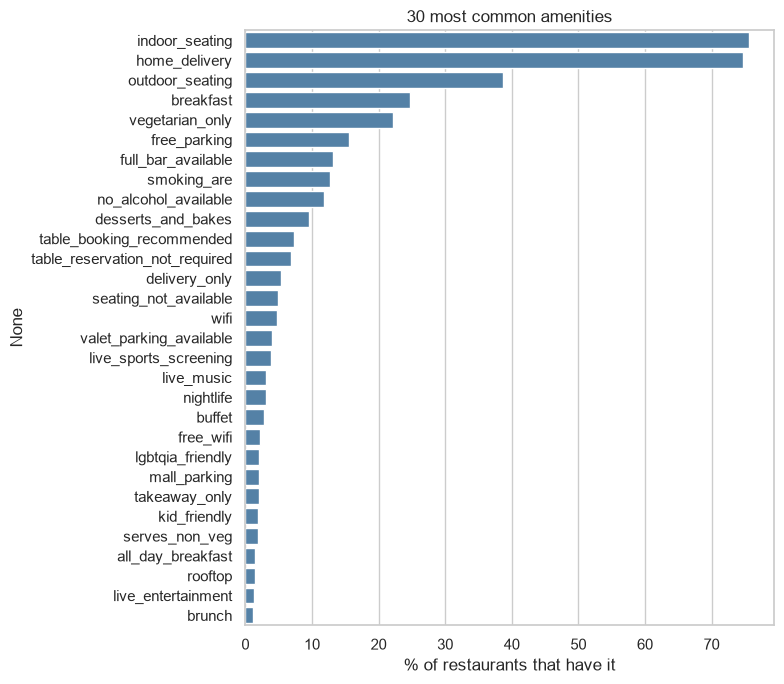

In [3]:
amen = X[[n for n in names if groups[n] == "amenity"]]
prev = amen.mean().sort_values(ascending=False)
print(f"Amenity columns: {len(prev)}")
for t in [0.005, 0.01, 0.02, 0.05]:
    print(f"  prevalence below {t:.1%}: {(prev < t).sum()} columns")

plt.figure(figsize=(8, 7))
sns.barplot(x=prev.head(30).values * 100, y=prev.head(30).index, color="steelblue")
plt.xlabel("% of restaurants that have it"); plt.title("30 most common amenities")
plt.tight_layout(); plt.show()

Many amenities are extremely rare (under 1% of restaurants). A rule such as "keep features present in at least 1% of restaurants" is what `features.py` used for the models in notebooks 04 and 05. Here we keep all of them and let the selection methods decide.

## 3. Step 2: filter methods (score each feature on its own)

- **ANOVA F-score:** how strongly the feature separates highly rated from other restaurants.
- **Mutual information:** captures any kind of dependence, not just linear.
- **Correlation with the rating:** direction and strength against the numeric rating.

In [4]:
is_discrete = np.array([groups[n] != "numeric" for n in names])

f_scores, _ = f_classif(X, y)
mi = mutual_info_classif(X, y, discrete_features=is_discrete, random_state=RANDOM_STATE)
corr_rating = X.apply(lambda c: np.corrcoef(c, rated["rating"])[0, 1])

filt = pd.DataFrame({"group": groups, "F_score": f_scores, "mutual_info": mi, "corr_with_rating": corr_rating})
filt["rank_F"] = filt["F_score"].rank(ascending=False)
filt["rank_MI"] = filt["mutual_info"].rank(ascending=False)

print("Top 15 by ANOVA F-score")
display(filt.sort_values("F_score", ascending=False).head(15).round(3))
print("Top 15 by mutual information")
display(filt.sort_values("mutual_info", ascending=False).head(15).round(4))
rho = stats.spearmanr(filt["F_score"], filt["mutual_info"])[0]
print(f"Rank agreement between the two filters (Spearman): {rho:.2f}")

Top 15 by ANOVA F-score


,group,F_score,mutual_info,corr_with_rating,rank_F,rank_MI
cost_capped,numeric,1049.355,0.042,0.337,1.0,2.0
n_amenities,numeric,932.948,0.048,0.336,2.0,1.0
table_booking_recommended,amenity,739.616,0.029,0.283,3.0,3.0
valet_parking_available,amenity,542.921,0.021,0.243,4.0,4.0
live_sports_screening,amenity,476.629,0.018,0.242,5.0,7.0
live_music,amenity,463.187,0.017,0.215,6.0,9.0
cuis_continental,cuisine,428.222,0.018,0.234,7.0,8.0
nightlife,amenity,424.231,0.016,0.205,8.0,13.0
cuis_italian,cuisine,389.954,0.016,0.231,9.0,12.0
full_bar_available,amenity,380.471,0.018,0.190,10.0,6.0


Top 15 by mutual information


,group,F_score,mutual_info,corr_with_rating,rank_F,rank_MI
n_amenities,numeric,932.9481,0.0478,0.3357,2.0,1.0
cost_capped,numeric,1049.3549,0.0420,0.3375,1.0,2.0
table_booking_recommended,amenity,739.6163,0.0293,0.2831,3.0,3.0
valet_parking_available,amenity,542.9215,0.0206,0.2426,4.0,4.0
n_cuisines,numeric,297.8451,0.0189,0.2008,13.0,5.0
full_bar_available,amenity,380.4711,0.0185,0.1897,10.0,6.0
live_sports_screening,amenity,476.6291,0.0183,0.2417,5.0,7.0
cuis_continental,cuisine,428.2225,0.0182,0.2339,7.0,8.0
live_music,amenity,463.1872,0.0174,0.2147,6.0,9.0
accepts_cards,numeric,222.3088,0.0168,0.1905,16.0,10.0


Rank agreement between the two filters (Spearman): 0.99


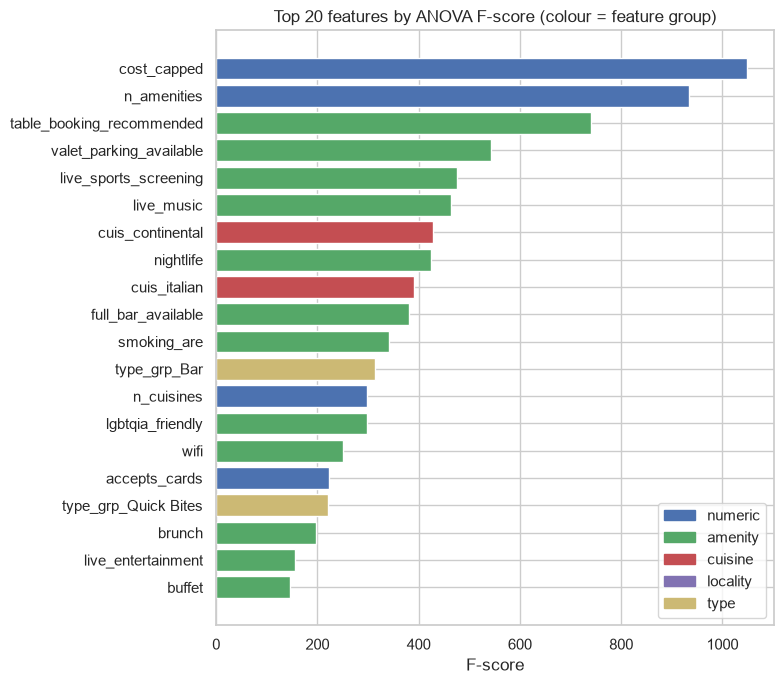

In [5]:
top = filt.sort_values("F_score", ascending=False).head(20).iloc[::-1]
colors = top["group"].map({"numeric": "#4c72b0", "amenity": "#55a868", "cuisine": "#c44e52",
                           "locality": "#8172b2", "restaurant type": "#ccb974"})
plt.figure(figsize=(8, 7))
plt.barh(top.index, top["F_score"], color=colors)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#ccb974"]]
plt.legend(handles, ["numeric", "amenity", "cuisine", "locality", "type"], loc="lower right")
plt.title("Top 20 features by ANOVA F-score (colour = feature group)"); plt.xlabel("F-score"); plt.tight_layout(); plt.show()

## 4. Step 3: redundancy (features that say the same thing)

If two amenities almost always appear together, keeping both adds nothing. We look at correlations between the more common amenities.

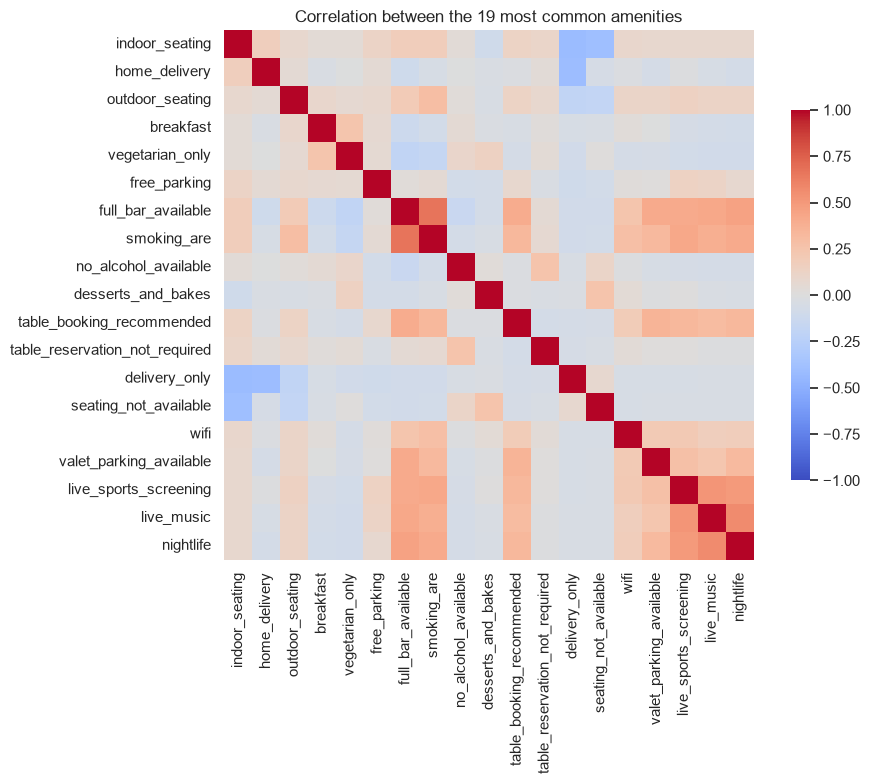

Pairs with |correlation| >= 0.5: 3


,feature_1,feature_2,corr
121,full_bar_available,smoking_are,0.67
341,live_music,nightlife,0.57
321,live_sports_screening,live_music,0.52


In [6]:
common = prev[prev >= 0.03].index.tolist()
cm = amen[common].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7})
plt.title(f"Correlation between the {len(common)} most common amenities"); plt.tight_layout(); plt.show()

pairs = (cm.where(np.triu(np.ones(cm.shape, dtype=bool), k=1)).stack().rename("corr").reset_index()
           .rename(columns={"level_0": "feature_1", "level_1": "feature_2"}))
pairs = pairs[pairs["corr"].abs() >= 0.5].sort_values("corr", ascending=False)
print("Pairs with |correlation| >= 0.5:", len(pairs))
pairs.round(2).head(12)

## 5. Step 4: model-based selection (embedded and wrapper methods)

- **L1 (Lasso) logistic regression:** the penalty drives unhelpful coefficients to exactly zero.
- **Random Forest importance:** how much each feature reduces impurity across the trees.
- **RFE (recursive feature elimination):** repeatedly fits a model and removes the weakest features.

Each method nominates its top 20. A feature picked by several independent methods is a **consensus** feature.

In [7]:
K = 20

l1 = LogisticRegression(penalty="l1", solver="liblinear", C=0.05, class_weight="balanced", random_state=RANDOM_STATE).fit(X, y)
l1_coef = pd.Series(np.abs(l1.coef_[0]), index=names)
print(f"L1 logistic kept {(l1_coef > 0).sum()} of {len(names)} features")

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced_subsample",
                            n_jobs=-1, random_state=RANDOM_STATE).fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=names)

rfe = RFE(LogisticRegression(max_iter=3000, class_weight="balanced"), n_features_to_select=K, step=5).fit(X, y)
rfe_sel = pd.Series(rfe.support_, index=names)

picks = pd.DataFrame({
    "F-score": filt["F_score"].rank(ascending=False) <= K,
    "Mutual info": filt["mutual_info"].rank(ascending=False) <= K,
    "L1 logistic": l1_coef.rank(ascending=False, method="first") <= K,
    "Random Forest": rf_imp.rank(ascending=False) <= K,
    "RFE": rfe_sel,
})
picks["votes_for"] = picks.sum(axis=1)
picks["group"] = groups
consensus = picks[picks["votes_for"] >= 3].sort_values("votes_for", ascending=False)
print(f"\nFeatures chosen by at least 3 of the 5 methods: {len(consensus)}")
consensus[["votes_for", "group"]]

L1 logistic kept 32 of 150 features

Features chosen by at least 3 of the 5 methods: 14


,votes_for,group
table_booking_recommended,5,amenity
cost_capped,4,numeric
n_amenities,4,numeric
accepts_cards,4,numeric
full_bar_available,4,amenity
n_cuisines,4,numeric
brunch,3,amenity
type_grp_Quick Bites,3,restaurant type
valet_parking_available,3,amenity
live_music,3,amenity


Consensus features by group:
group
amenity            6
numeric            4
cuisine            3
restaurant type    1

Nominations per method (always 20 ): {'F-score': 20, 'Mutual info': 20, 'L1 logistic': 20, 'Random Forest': 20, 'RFE': 20}


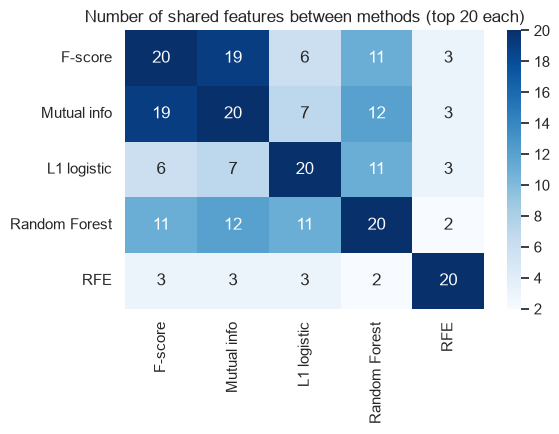

In [8]:
# Which feature groups survive?
print("Consensus features by group:"); print(consensus["group"].value_counts().to_string())
print("\nNominations per method (always", K, "):", picks.drop(columns=["votes_for", "group"]).sum().to_dict())
agree = pd.DataFrame({a: {b: (picks[a] & picks[b]).sum() for b in picks.columns[:5]} for a in picks.columns[:5]})
plt.figure(figsize=(6, 4.5)); sns.heatmap(agree, annot=True, fmt="d", cmap="Blues")
plt.title("Number of shared features between methods (top 20 each)"); plt.tight_layout(); plt.show()

## 6. Does feature selection help? (honest evaluation)

We compare cross-validated ROC-AUC when keeping only the best `k` features. The selection (`SelectKBest`) is **inside the pipeline**, so it is re-done on each training fold and never sees the validation fold.

,Logistic Regression,Random Forest
5,0.738,0.690
10,0.751,0.736
15,0.755,0.735
20,0.770,0.757
30,0.797,0.788
40,0.809,0.803
60,0.814,0.810
all (150),0.825,0.832


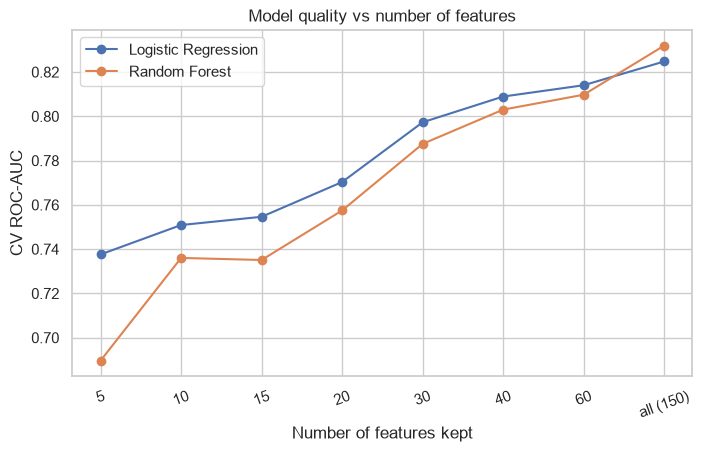

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ks = [5, 10, 15, 20, 30, 40, 60, X.shape[1]]

def curve(model):
    out = []
    for k in ks:
        pipe = Pipeline([("sel", SelectKBest(f_classif, k=k)), ("model", model)])
        out.append(cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=1).mean())
    return out

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=150, min_samples_leaf=3, class_weight="balanced_subsample",
                                            n_jobs=-1, random_state=RANDOM_STATE),
}
curves = pd.DataFrame({name: curve(m) for name, m in models.items()}, index=[str(k) if k != X.shape[1] else f"all ({k})" for k in ks])
display(curves.round(3))

plt.figure(figsize=(8, 4.5))
for name in curves:
    plt.plot(range(len(ks)), curves[name], "o-", label=name)
plt.xticks(range(len(ks)), curves.index, rotation=20); plt.xlabel("Number of features kept"); plt.ylabel("CV ROC-AUC")
plt.title("Model quality vs number of features"); plt.legend(); plt.show()

In [10]:
# Selection leakage demo: choosing features using ALL labels first, then cross-validating, looks better than it should.
k = 20
leaky_cols = filt.sort_values("F_score", ascending=False).head(k).index
lr = LogisticRegression(max_iter=3000, class_weight="balanced")
leaky = cross_val_score(lr, X[leaky_cols], y, cv=cv, scoring="roc_auc").mean()
honest = cross_val_score(Pipeline([("sel", SelectKBest(f_classif, k=k)), ("model", lr)]), X, y, cv=cv, scoring="roc_auc").mean()
print(f"Select top {k} on ALL data, then CV (leaky): {leaky:.4f}")
print(f"Select top {k} INSIDE each fold (honest):    {honest:.4f}")
print(f"Optimism from leakage: {leaky - honest:+.4f}")

Select top 20 on ALL data, then CV (leaky): 0.7698
Select top 20 INSIDE each fold (honest):    0.7703
Optimism from leakage: -0.0005


With thousands of rows and only a few strong signals, the leakage is small here. It can be much larger on small datasets with many features (for example gene or medical data), which is why the rule matters. In the viva you can say: *"we always put selection inside the cross-validation pipeline."*

## 7. PCA: compressing the amenities

PCA creates new axes (principal components) that capture as much variation as possible. We first apply it to the 86 amenity columns alone, to see whether they collapse into a few underlying "styles" of restaurant.

Components needed for 50% of the variance: 5 (of 86)
Components needed for 80% of the variance: 14 (of 86)
Components needed for 90% of the variance: 24 (of 86)
Components needed for 95% of the variance: 35 (of 86)


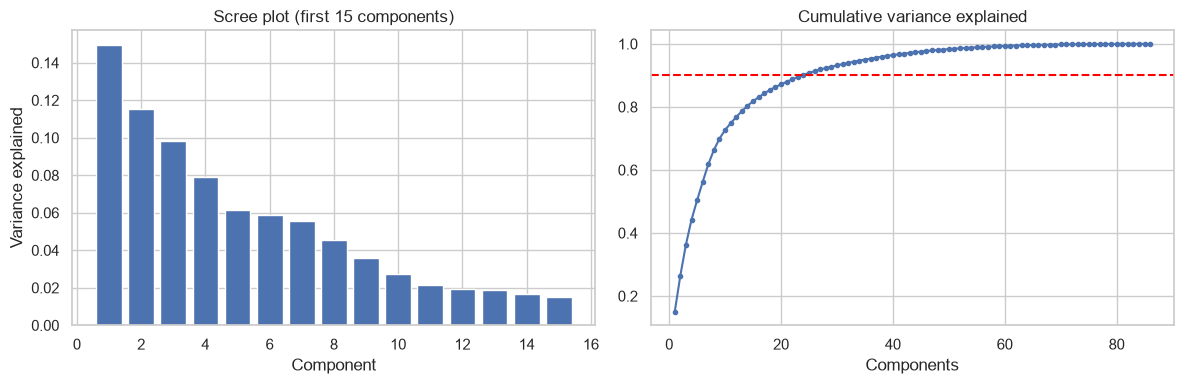

In [11]:
A = rated[spec_full["amenity_keep"]].astype(float)
pca = PCA(random_state=RANDOM_STATE).fit(A)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

for t in [0.5, 0.8, 0.9, 0.95]:
    print(f"Components needed for {t:.0%} of the variance: {int(np.searchsorted(cum, t) + 1)} (of {A.shape[1]})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, 16), evr[:15]); ax[0].set_title("Scree plot (first 15 components)"); ax[0].set_xlabel("Component"); ax[0].set_ylabel("Variance explained")
ax[1].plot(range(1, len(cum) + 1), cum, "o-", markersize=3)
ax[1].axhline(0.9, color="red", linestyle="--"); ax[1].set_title("Cumulative variance explained"); ax[1].set_xlabel("Components")
plt.tight_layout(); plt.show()

In [12]:
# What do the first components mean? Look at their loadings.
load = pd.DataFrame(pca.components_[:3].T, index=A.columns, columns=["PC1", "PC2", "PC3"])
for pc in ["PC1", "PC2"]:
    print(f"\n{pc}: strongest positive and negative amenity loadings")
    s = load[pc].sort_values()
    display(pd.concat([s.tail(6).iloc[::-1], s.head(3)]).round(2).to_frame())


PC1: strongest positive and negative amenity loadings


,PC1
outdoor_seating,0.55
smoking_are,0.42
full_bar_available,0.41
indoor_seating,0.34
table_booking_recommended,0.21
live_sports_screening,0.16
delivery_only,-0.12
seating_not_available,-0.12
vegetarian_only,-0.11



PC2: strongest positive and negative amenity loadings


,PC2
vegetarian_only,0.51
breakfast,0.51
home_delivery,0.32
outdoor_seating,0.31
indoor_seating,0.27
free_parking,0.13
full_bar_available,-0.25
smoking_are,-0.18
delivery_only,-0.16


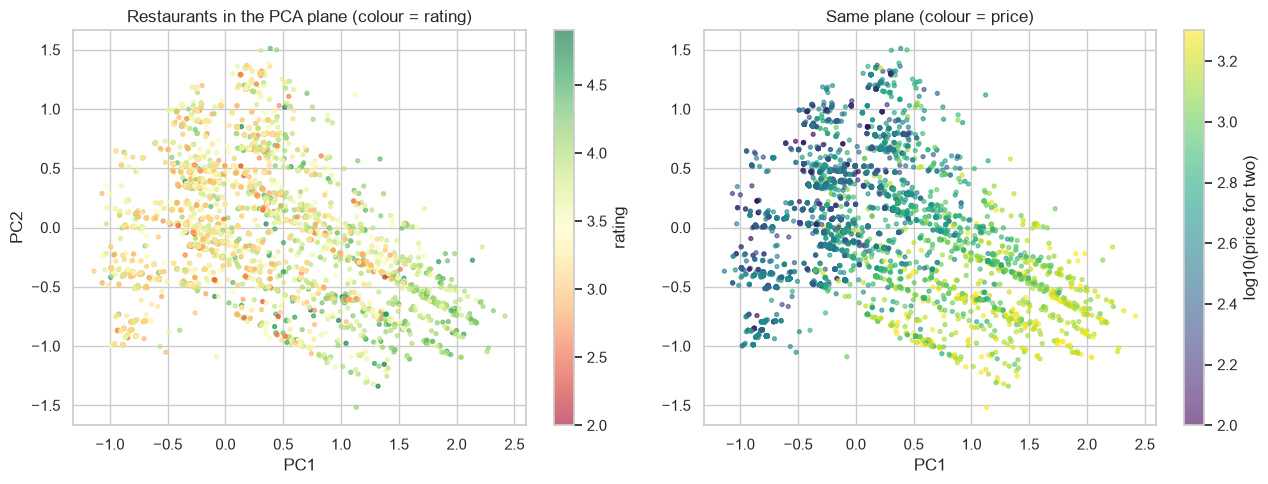

,count,mean
PC1_band,,
"(-1.138, -0.385]",1536,3.40
"(-0.385, -0.233]",2087,3.37
"(-0.233, -0.0209]",1061,3.40
"(-0.0209, 0.326]",1451,3.40
"(0.326, 2.42]",1534,3.62


In [13]:
scores = pca.transform(A)[:, :2]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sc = ax[0].scatter(scores[:, 0], scores[:, 1], c=rated["rating"], cmap="RdYlGn", s=8, alpha=0.6)
plt.colorbar(sc, ax=ax[0], label="rating"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].set_title("Restaurants in the PCA plane (colour = rating)")
sc2 = ax[1].scatter(scores[:, 0], scores[:, 1], c=np.log10(rated["cost_capped"]), cmap="viridis", s=8, alpha=0.6)
plt.colorbar(sc2, ax=ax[1], label="log10(price for two)"); ax[1].set_xlabel("PC1"); ax[1].set_title("Same plane (colour = price)")
plt.tight_layout(); plt.show()

q = pd.qcut(scores[:, 0], 5, duplicates="drop")
rated.assign(PC1_band=q).groupby("PC1_band", observed=True)["rating"].agg(["count", "mean"]).round(2)

## 8. Does PCA help a model?

We feed a model the first `k` principal components of the **whole** feature matrix (inside the pipeline, so it is re-fitted on every training fold) and compare it with the raw features.

In [14]:
kp = [5, 10, 20, 30, 50, 80]
pca_scores = []
for k in kp:
    pipe = Pipeline([("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
                     ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))])
    pca_scores.append(cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").mean())
raw_score = cross_val_score(LogisticRegression(max_iter=3000, class_weight="balanced"), X, y, cv=cv, scoring="roc_auc").mean()

res = pd.DataFrame({"PCA components": kp, "CV ROC-AUC": pca_scores}).round(3)
print(f"Raw features (no PCA, {X.shape[1]} columns): {raw_score:.3f}")
res

Raw features (no PCA, 150 columns): 0.825


,PCA components,CV ROC-AUC
0,5,0.750
1,10,0.810
2,20,0.819
3,30,0.820
4,50,0.826
5,80,0.825


## 9. Save the selected features

In [15]:
os.makedirs("../ml/models", exist_ok=True)
out = {
    "note": "Exploratory ranking on all rated restaurants (target: rating >= 4.0). Use for choosing features in clustering and the dashboard, not for reporting scores.",
    "n_features_total": int(X.shape[1]),
    "consensus_features": consensus.index.tolist(),
    "per_method_top20": {m: picks.index[picks[m]].tolist() for m in picks.columns[:5]},
    "amenities_with_prevalence_under_1pct": prev[prev < 0.01].index.tolist(),
}
with open("../ml/models/selected_features.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved ../ml/models/selected_features.json |", len(out["consensus_features"]), "consensus features")

Saved ../ml/models/selected_features.json | 14 consensus features


## 10. Summary and findings

### Key findings

1. **Most amenity columns are rare.** About two-thirds of the 85 usable amenity columns occur in fewer than 1% of restaurants, and one (`egg_preparations`) never occurs among rated restaurants, so it was dropped. This is why `features.py` keeps only amenities present in at least 1% of restaurants.
2. **Amenities are not very redundant.** Only three pairs correlate at 0.5 or above: full bar and smoking area (0.67), live music and nightlife (0.57), live sports screening and live music (0.52). So there is little to remove by merging near-duplicates.
3. **The five selection methods broadly agree on the top signals.** The two filters (F-score and mutual information) rank features almost identically (Spearman about 0.99). Fourteen features were picked by at least 3 of 5 methods:
   - **Numeric (4):** price, number of amenities, number of cuisines, accepts cards
   - **Amenities (6):** table booking recommended, full bar, brunch, valet parking, live music, smoking area
   - **Cuisines (3):** desserts, continental, Italian
   - **Type (1):** Quick Bites
4. **Different methods favour different things.** RFE mostly picked locality dummies, while the filters favoured price and premium amenities. This is exactly why a consensus across methods is safer than trusting one.
5. **Fewer features means lower accuracy here.** Cross-validated ROC-AUC rises steadily as features are added: about 0.74 with 5 features, 0.77 with 20, 0.81 with 40, and 0.825 with all 150 (Random Forest is similar, up to about 0.83). Many small signals (locality, cuisines, amenities) add up. So in this project **feature selection is for simplicity and interpretation, not for accuracy**. That is a perfectly good finding, and an honest one.
6. **Selection leakage was negligible here** (selecting on all labels first was no better than selecting inside each fold, a difference of about 0.0005). We still do selection inside the pipeline as a rule, because on smaller datasets the difference can be large.
7. **PCA compresses the amenities moderately.** Five components capture about half of the amenity variance, and 24 components are needed for 90% (out of 86). PC1 is a "bar and nightlife" axis (outdoor seating, smoking area, full bar, table booking). PC2 is a "casual vegetarian, breakfast and delivery" axis. Restaurants in the top PC1 fifth average about 3.62, versus about 3.40 for the rest.
8. **PCA before a model costs nothing at about 50 components.** Logistic regression on 50 components scores about 0.826 against 0.825 on the raw 150 columns, and 20 components give about 0.819. With only 5 components it drops to about 0.75. The price of PCA is that the components are harder to explain than named features.

### What to use later
- **Dashboard and Opening Advisor:** the 14 consensus features are a good short list of "what to ask the user" (price band, number of amenities, bar, brunch, valet parking, and so on).
- **Clustering (notebook 07):** use price, rating, votes, and review mix; PCA on amenities can optionally give a 2D picture.
- **Models:** keep all features for accuracy (as in notebooks 04 and 05), since selection did not improve the score.

**Next:** `07_clustering.ipynb` (K-Means on restaurant segments, DBSCAN/hierarchical for comparison, and a Hidden Gems segment).